<a href="https://colab.research.google.com/github/Saiful-2/multi-agent-ai-decision-support/blob/main/notebooks/02_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELL 01
# PROJECT INFORMATION
# ============================================================

PROJECT_NAME = "Multi-Agent AI Decision Support System"

NOTEBOOK_NAME = "02_embeddings.ipynb"

AUTHOR = "Mohammad Saiful Alam"

PURPOSE = """
Load chunks,
generate embeddings,
analyze embeddings,
save embedding vectors.
"""

print(PROJECT_NAME)

print(NOTEBOOK_NAME)

print(AUTHOR)

Multi-Agent AI Decision Support System
02_embeddings.ipynb
Mohammad Saiful Alam


In [2]:
# ============================================================
# CELL 02
# INSTALL REQUIRED LIBRARIES
# ============================================================

!pip install -q sentence-transformers
!pip install -q matplotlib
!pip install -q seaborn
!pip install -q joblib

In [3]:
# ============================================================
# CELL 03
# IMPORT LIBRARIES
# ============================================================

import random

import numpy as np

import pickle

import joblib

import matplotlib.pyplot as plt

import seaborn as sns

from sentence_transformers import (

    SentenceTransformer

)

from google.colab import files

print(

    "Libraries loaded successfully."

)

Libraries loaded successfully.


In [4]:
# ============================================================
# CELL 04
# RANDOM SEED
# ============================================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

print(

    "Random seed fixed:",

    SEED

)

Random seed fixed: 42


In [5]:
# ============================================================
# CELL 05
# UPLOAD CHUNKS FILE
# ============================================================

uploaded = files.upload()

Saving chunks.pkl to chunks.pkl


In [6]:
# ============================================================
# CELL 06
# LOAD CHUNKS
# ============================================================

with open(

    "chunks.pkl",

    "rb"

) as file:

    chunks = pickle.load(

        file

    )

print(

    "Total chunks loaded:",

    len(chunks)

)

Total chunks loaded: 40


In [7]:
# ============================================================
# CELL 07
# EXTRACT TEXT
# ============================================================

texts = [

    chunk.page_content

    for chunk in chunks

]

print(

    "Total text chunks:",

    len(texts)

)

Total text chunks: 40


In [8]:
# ============================================================
# CELL 08
# PREVIEW SAMPLE TEXT
# ============================================================

texts[0][:1000]

'Chevron Clinical Lab (Pte) Ltd\n12/12 O R Nizam Road, Panchlaish, Chittagong. 1 3 2 1 2 4 9 2\nHotline: (+88) 01755666969, 01713487903\nEmail: info@chevronlab.com\nWeb: https://chevronlab.com/\n5418393Invoice #\nC61Patient IDMrs Shamima Akter\nName\nProf.Dr. Uzzal Kanti Das MBBS.FCPS(Medicine)\nF\nSex\n32Y\nAge\nBooked\n14/03/26 10 PMPrinted\nPhone\n01836421292\nReferred By\n172.68.221.164 1 / 1\nHaematology Examination\nEstimations are carried out by  Sysmex XN 2000, ABBOTT Cell Dyn Ruby, Orphee Mythic 22ALL, Emerald 22ALL\nParameter UnitsResult Reference Range(s)\nCBC (Complete Blood Count )\n    Haemoglobin %12.6   g/dL 78.7 % Male: 13 - 17 g/dL, Female: 12 - 15 g/dL\n    Erythrocyte Sedimentation Rate mm40 At the end of 1st hr (Westergren):\nMale: 0 - 10 mm, Female: 0 - 20 mm\n    Total WBC /Cmm.6,600 Adult: 4000 - 10000/Cmm\nInfants (1yr.): 6000 - 18000/Cmm\nChildhood (4-7 yr.): 5000 - 15000/Cmm\n    Total RBC million/uL4.39 4.2 - 6.2 million/uL\n    PCV/HCT %40.0 Male: 47 - 54%,

In [9]:
# ============================================================
# CELL 09
# LOAD EMBEDDING MODEL
# ============================================================

MODEL_NAME = (

    "all-MiniLM-L6-v2"

)

model = SentenceTransformer(

    MODEL_NAME

)

print(

    "Model loaded:",

    MODEL_NAME

)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded: all-MiniLM-L6-v2


In [10]:
# ============================================================
# CELL 10
# GENERATE EMBEDDINGS
# ============================================================

embeddings = model.encode(

    texts,

    show_progress_bar=True,

    convert_to_numpy=True

)

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

In [11]:
# ============================================================
# CELL 11
# CHECK EMBEDDING SHAPE
# ============================================================

print(

    "Embedding Shape:",

    embeddings.shape

)

Embedding Shape: (40, 384)


In [12]:
# ============================================================
# CELL 12
# CHECK DATA TYPE
# ============================================================

embeddings.dtype

dtype('float32')

In [13]:
# ============================================================
# CELL 13
# VECTOR STATISTICS
# ============================================================

print(

    "Minimum:",

    np.min(

        embeddings

    )

)

print(

    "Maximum:",

    np.max(

        embeddings

    )

)

print(

    "Mean:",

    np.mean(

        embeddings

    )

)

print(

    "Standard Deviation:",

    np.std(

        embeddings

    )

)

Minimum: -0.19538693
Maximum: 0.20414431
Mean: -0.0018027236
Standard Deviation: 0.050999187


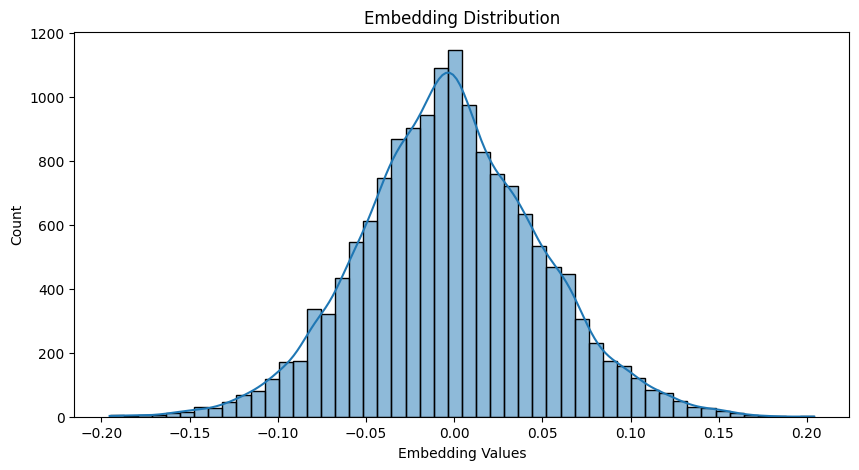

In [14]:
# ============================================================
# CELL 14
# VISUALIZE EMBEDDING DISTRIBUTION
# ============================================================

plt.figure(

    figsize=(10,5)

)

sns.histplot(

    embeddings.flatten(),

    bins=50,

    kde=True

)

plt.title(

    "Embedding Distribution"

)

plt.xlabel(

    "Embedding Values"

)

plt.show()

In [15]:
# ============================================================
# CELL 15
# SAVE EMBEDDINGS
# ============================================================

joblib.dump(

    embeddings,

    "embeddings.pkl"

)

print(

    "Embeddings saved."

)

Embeddings saved.


In [16]:
# ============================================================
# CELL 16
# DOWNLOAD EMBEDDINGS
# ============================================================

files.download(

    "embeddings.pkl"

)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
# ============================================================
# CELL 17
# SAVE TEXTS
# ============================================================

joblib.dump(

    texts,

    "texts.pkl"

)

print(

    "Texts saved."

)

Texts saved.


In [18]:
# ============================================================
# CELL 18
# DOWNLOAD TEXT FILE
# ============================================================

files.download(

    "texts.pkl"

)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# ============================================================
# CELL 19
# COMPLETION
# ============================================================

print(

    "Phase 2 Completed Successfully"

)

print(

    "Ready for 03_vector_database.ipynb"

)

Phase 2 Completed Successfully
Ready for 03_vector_database.ipynb
